Loaded: /Users/seb/Desktop/github/RSA-multilingual/results/mbert_k20_anypos/rdm_similarity_all_layers.csv
Columns: ['pair', 'lang1', 'lang2', 'layer', 'seed', 'rho_obs', 'null_mean', 'null_ci_lo', 'null_ci_hi', 'delta', 'p_two_sided', 'z_vs_null', 'n_concepts', 'n_perm', 'rdm_metric', 'q_fdr_bh']
    pair lang1 lang2  layer     seed   rho_obs  null_mean  null_ci_lo  \
0  bg-da    bg    da    -12  6473655  0.044274  -0.002137   -0.026254   
1  bg-da    bg    da    -11  6473672  0.054174  -0.000097   -0.022638   
2  bg-da    bg    da    -10  6473689  0.074869  -0.000883   -0.022915   
3  bg-da    bg    da     -9  6473706  0.082753  -0.001451   -0.022098   
4  bg-da    bg    da     -8  6473723  0.130951   0.000027   -0.021871   

   null_ci_hi     delta  p_two_sided  z_vs_null  n_concepts  n_perm  \
0    0.026278  0.046411     0.009901   3.456776        2000     100   
1    0.023171  0.054271     0.009901   4.373781        2000     100   
2    0.023924  0.075752     0.009901   5.706510   

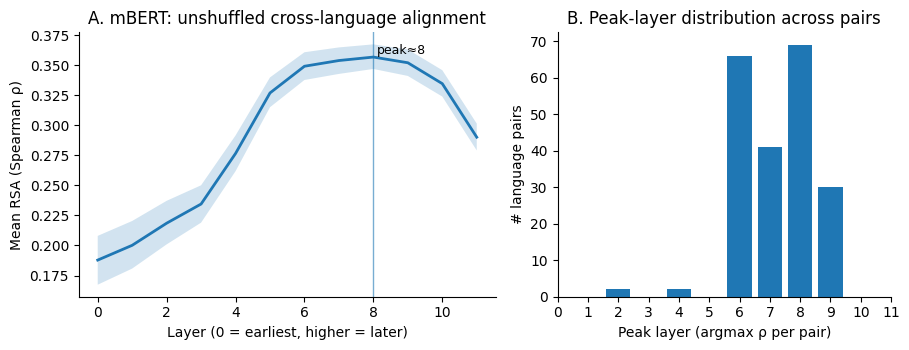

Saved: /Users/seb/Desktop/github/RSA-multilingual/results/mbert_k20_anypos/figs_cognition/Fig4_mBERT_unshuffled_A_mean_B_peak.pdf
Saved: /Users/seb/Desktop/github/RSA-multilingual/results/mbert_k20_anypos/figs_cognition/Fig4_mBERT_unshuffled_A_mean_B_peak.png


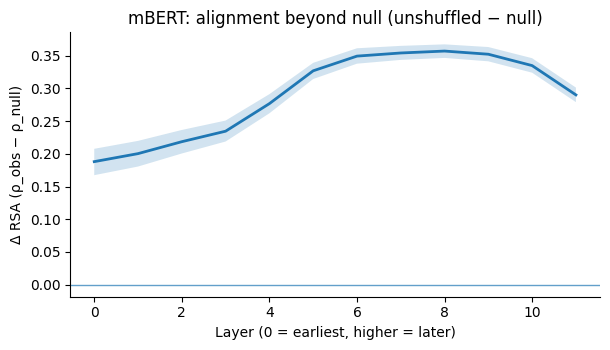

Saved: /Users/seb/Desktop/github/RSA-multilingual/results/mbert_k20_anypos/figs_cognition/Fig4C_mBERT_delta_obs_minus_null.pdf
Saved: /Users/seb/Desktop/github/RSA-multilingual/results/mbert_k20_anypos/figs_cognition/Fig4C_mBERT_delta_obs_minus_null.png


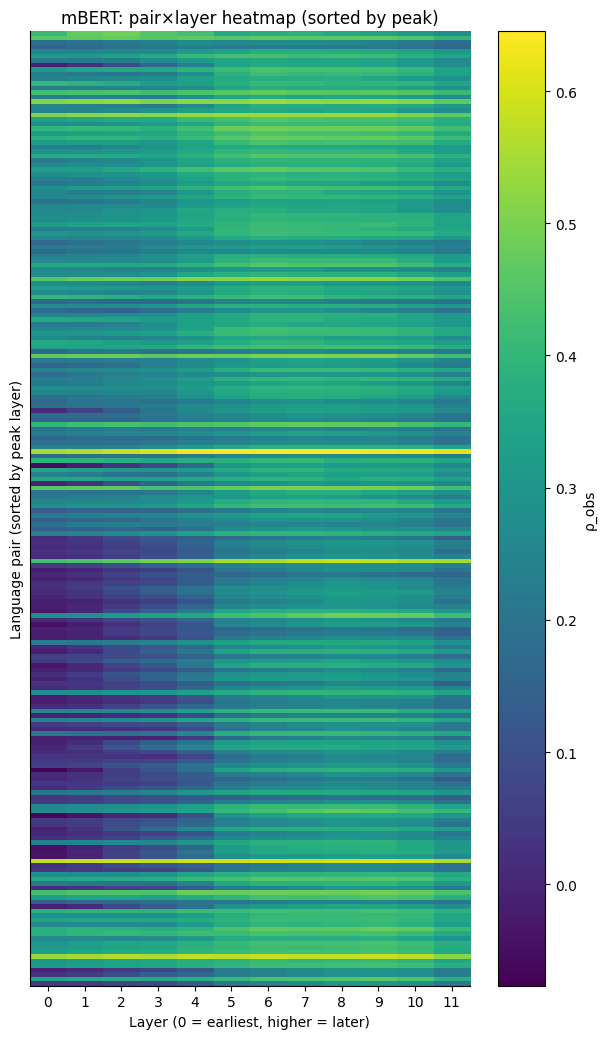

Saved: /Users/seb/Desktop/github/RSA-multilingual/results/mbert_k20_anypos/figs_cognition/FigS_mBERT_pair_by_layer_heatmap_sorted.pdf
Saved: /Users/seb/Desktop/github/RSA-multilingual/results/mbert_k20_anypos/figs_cognition/FigS_mBERT_pair_by_layer_heatmap_sorted.png


In [19]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ====== CONFIG (only change paths if needed) ======
CSV = "/Users/seb/Desktop/github/RSA-multilingual/results/mbert_k20_anypos/rdm_similarity_all_layers.csv"
OUTDIR = os.path.join(os.path.dirname(CSV), "figs_cognition")
os.makedirs(OUTDIR, exist_ok=True)

MODEL_LABEL = "mBERT"  # figure label (short, Cognition-style)
N_BOOT = 4000          # bootstrap draws for CI (stable but not crazy slow)
ALPHA = 0.05           # 95% CI

# ====== Helpers ======
def pick_col(cols, candidates):
    """Return first matching column name from candidates."""
    for c in candidates:
        if c in cols:
            return c
    return None

def bootstrap_ci_mean(x, n_boot=4000, alpha=0.05, seed=0):
    """Bootstrap CI for the mean."""
    x = np.asarray(x, dtype=float)
    x = x[~np.isnan(x)]
    if len(x) == 0:
        return (np.nan, np.nan)
    rng = np.random.default_rng(seed)
    boots = rng.choice(x, size=(n_boot, len(x)), replace=True).mean(axis=1)
    lo = np.quantile(boots, alpha / 2)
    hi = np.quantile(boots, 1 - alpha / 2)
    return lo, hi

def layer_to_plot_index(layer_series):
    """
    Map arbitrary layer labels to 0..L-1 in ascending order.
    Works for -12..-1, 0..11, etc.
    """
    uniq = np.sort(pd.unique(layer_series))
    mapping = {v: i for i, v in enumerate(uniq)}
    return layer_series.map(mapping), mapping

def clean_axes(ax):
    """Cognition-ish minimal axes (no boxy top/right spines)."""
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

# ====== Load ======
df = pd.read_csv(CSV)
cols = df.columns.tolist()
print("Loaded:", CSV)
print("Columns:", cols)
print(df.head())

# ====== Auto-detect columns (no manual choosing) ======
col_pair  = pick_col(cols, ["pair", "lang_pair", "language_pair", "pair_id", "lp"])
col_layer = pick_col(cols, ["layer", "layer_idx", "layer_id", "L"])
col_obs   = pick_col(cols, ["rho_obs", "obs", "rho", "rsa", "rdm_rho", "rdm_similarity", "score"])

# null / permutation mean (optional)
col_null  = pick_col(cols, ["rho_null_mean", "null_mean", "rho_null", "perm_mean", "rho_perm_mean", "shuffle_mean", "rho_shuf_mean"])

# sanity check
if col_layer is None or col_obs is None:
    raise ValueError(
        "Could not auto-detect required columns.\n"
        f"Found columns: {cols}\n"
        "Need at least a layer column (e.g., 'layer') and an observed RSA column (e.g., 'rho_obs')."
    )

# If pair column is missing, we can still draw the mean curve (Fig A),
# but we cannot draw the peak distribution / sorted heatmap.
has_pair = col_pair is not None

print("\nDetected:")
print("  pair:", col_pair)
print("  layer:", col_layer)
print("  obs :", col_obs)
print("  null:", col_null)

# ====== Create layer_plot (0..L-1) for reader-friendly x-axis ======
df = df.copy()
df["layer_plot"], layer_map = layer_to_plot_index(df[col_layer])
# Keep original layer labels for reporting
layers_plot = np.sort(df["layer_plot"].unique())

# ====== Fig 4A: layer-wise mean curve with 95% CI ======
mean_obs, lo_obs, hi_obs = [], [], []
for lp in layers_plot:
    vals = df.loc[df["layer_plot"] == lp, col_obs].astype(float).values
    mean_obs.append(np.nanmean(vals))
    lo, hi = bootstrap_ci_mean(vals, n_boot=N_BOOT, alpha=ALPHA, seed=1234 + int(lp))
    lo_obs.append(lo); hi_obs.append(hi)
mean_obs = np.array(mean_obs); lo_obs = np.array(lo_obs); hi_obs = np.array(hi_obs)

# If null exists, also compute delta curve (optional Fig 4C)
have_delta = col_null is not None
if have_delta:
    df["delta"] = df[col_obs].astype(float) - df[col_null].astype(float)
    mean_d, lo_d, hi_d = [], [], []
    for lp in layers_plot:
        vals = df.loc[df["layer_plot"] == lp, "delta"].values
        mean_d.append(np.nanmean(vals))
        lo, hi = bootstrap_ci_mean(vals, n_boot=N_BOOT, alpha=ALPHA, seed=5678 + int(lp))
        lo_d.append(lo); hi_d.append(hi)
    mean_d = np.array(mean_d); lo_d = np.array(lo_d); hi_d = np.array(hi_d)

# ====== Fig 4B: peak-layer distribution (requires pair) ======
if has_pair:
    # for each pair, find layer with max obs
    peak = (df.sort_values([col_pair, "layer_plot"])
              .loc[df.groupby(col_pair)[col_obs].idxmax(), [col_pair, "layer_plot", col_obs]]
              .rename(columns={"layer_plot": "peak_layer_plot", col_obs: "peak_rho"}))
    peak_counts = peak["peak_layer_plot"].value_counts().sort_index()
else:
    peak = None
    peak_counts = None

# ====== Build Cognition-style multi-panel figure ======
# Panel A (mean curve) + Panel B (peak histogram). Optional Panel C (delta curve) goes as a separate figure for cleanliness.
fig, axes = plt.subplots(1, 2, figsize=(9.2, 3.6), gridspec_kw={"width_ratios":[1.25, 1.0]})

# Panel A
ax = axes[0]
ax.plot(layers_plot, mean_obs, linewidth=2)
ax.fill_between(layers_plot, lo_obs, hi_obs, alpha=0.2)
ax.set_xlabel("Layer (0 = earliest, higher = later)")
ax.set_ylabel("Mean RSA (Spearman ρ)")
ax.set_title(f"A. {MODEL_LABEL}: unshuffled cross-language alignment")
clean_axes(ax)

# mark peak layer of the mean curve
peak_lp = int(layers_plot[np.nanargmax(mean_obs)])
ax.axvline(peak_lp, linewidth=1, alpha=0.6)
ax.text(peak_lp + 0.1, np.nanmax(mean_obs), f"peak≈{peak_lp}", va="bottom", fontsize=9)

# Panel B
ax = axes[1]
ax.set_title("B. Peak-layer distribution across pairs")
ax.set_xlabel("Peak layer (argmax ρ per pair)")
ax.set_ylabel("# language pairs")
clean_axes(ax)

if has_pair:
    ax.bar(peak_counts.index.values, peak_counts.values)
    ax.set_xticks(layers_plot)
else:
    ax.text(0.5, 0.5, "No pair column found.\nCannot compute peak-layer distribution.",
            ha="center", va="center", transform=ax.transAxes)
    ax.set_xticks([])
    ax.set_yticks([])

fig.tight_layout()
figpath_pdf = os.path.join(OUTDIR, "Fig4_mBERT_unshuffled_A_mean_B_peak.pdf")
figpath_png = os.path.join(OUTDIR, "Fig4_mBERT_unshuffled_A_mean_B_peak.png")
fig.savefig(figpath_pdf)
fig.savefig(figpath_png, dpi=300)
plt.show()

print("Saved:", figpath_pdf)
print("Saved:", figpath_png)

# ====== Optional Fig 4C: delta curve (obs - null) if null column exists ======
if have_delta:
    fig = plt.figure(figsize=(6.2, 3.6))
    ax = plt.gca()
    ax.plot(layers_plot, mean_d, linewidth=2)
    ax.fill_between(layers_plot, lo_d, hi_d, alpha=0.2)
    ax.axhline(0, linewidth=1, alpha=0.7)
    ax.set_xlabel("Layer (0 = earliest, higher = later)")
    ax.set_ylabel("Δ RSA (ρ_obs − ρ_null)")
    ax.set_title(f"{MODEL_LABEL}: alignment beyond null (unshuffled − null)")
    clean_axes(ax)
    plt.tight_layout()

    figpath_pdf = os.path.join(OUTDIR, "Fig4C_mBERT_delta_obs_minus_null.pdf")
    figpath_png = os.path.join(OUTDIR, "Fig4C_mBERT_delta_obs_minus_null.png")
    plt.savefig(figpath_pdf)
    plt.savefig(figpath_png, dpi=300)
    plt.show()

    print("Saved:", figpath_pdf)
    print("Saved:", figpath_png)
else:
    print("\nNo null/perm-mean column detected -> skipping Δ(ρ_obs−ρ_null) figure.")

# ====== Supplementary: pair×layer heatmap sorted by peak (if pair exists) ======
if has_pair:
    mat = df.pivot_table(index=col_pair, columns="layer_plot", values=col_obs, aggfunc="mean")
    peak_lp_per_pair = mat.idxmax(axis=1)
    mat_sorted = mat.loc[peak_lp_per_pair.sort_values().index]

    fig = plt.figure(figsize=(6.2, 10.5))
    ax = plt.gca()
    im = ax.imshow(mat_sorted.values, aspect="auto")
    plt.colorbar(im, ax=ax, label="ρ_obs")
    ax.set_xlabel("Layer (0 = earliest, higher = later)")
    ax.set_ylabel("Language pair (sorted by peak layer)")
    ax.set_title(f"{MODEL_LABEL}: pair×layer heatmap (sorted by peak)")
    ax.set_yticks([])  # too many pairs to label cleanly
    ax.set_xticks(layers_plot)
    clean_axes(ax)
    plt.tight_layout()

    figpath_pdf = os.path.join(OUTDIR, "FigS_mBERT_pair_by_layer_heatmap_sorted.pdf")
    figpath_png = os.path.join(OUTDIR, "FigS_mBERT_pair_by_layer_heatmap_sorted.png")
    plt.savefig(figpath_pdf)
    plt.savefig(figpath_png, dpi=300)
    plt.show()

    print("Saved:", figpath_pdf)
    print("Saved:", figpath_png)
else:
    print("\nNo pair column detected -> skipping sorted pair×layer heatmap.")


[mBERT_RSA] Using CSV: /Users/seb/Desktop/github/RSA-multilingual/results/mbert_k20_anypos/rdm_similarity_all_layers.csv
[mBERT_RSA] Columns: ['pair', 'lang1', 'lang2', 'layer', 'seed', 'rho_obs', 'null_mean', 'null_ci_lo', 'null_ci_hi', 'delta', 'p_two_sided', 'z_vs_null', 'n_concepts', 'n_perm', 'rdm_metric', 'q_fdr_bh']
[QWEN_RSA] Using CSV: /Users/seb/Desktop/github/RSA-multilingual/results/qwen25_0p5b_k20_anypos/rdm_similarity_all_layers.csv
[QWEN_RSA] Columns: ['pair', 'lang1', 'lang2', 'layer', 'seed', 'rho_obs', 'null_mean', 'null_ci_lo', 'null_ci_hi', 'delta', 'p_two_sided', 'z_vs_null', 'n_concepts', 'n_perm', 'rdm_metric', 'q_fdr_bh']
[mBERT_FORM] Using CSV: /Users/seb/Desktop/github/RSA-multilingual/results/oneshot_form_controls_21lang_mbert_v3/summary/merged_pair_layer.csv
[mBERT_FORM] Columns: ['lang_a', 'lang_b', 'layer', 'rho_base', 'null_mean', 'null_std', 'rho_pert', 'delta', 'z', 'drop']
[mBERT_FORM] Also merging: /Users/seb/Desktop/github/RSA-multilingual/results/on

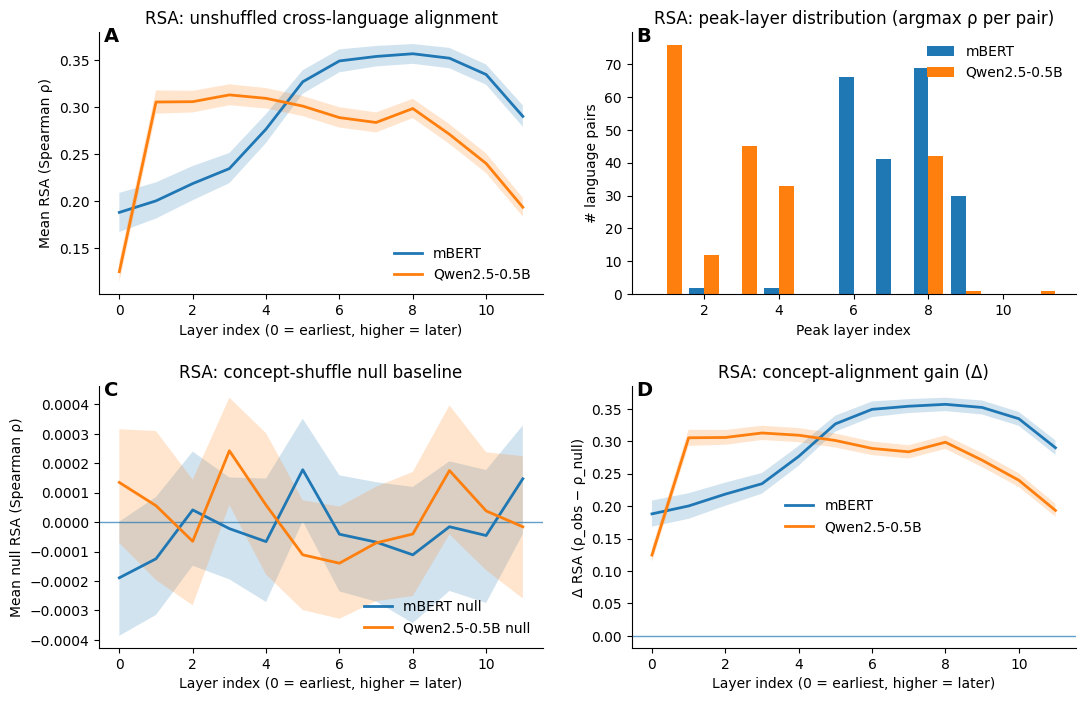

Saved: /Users/seb/Desktop/github/RSA-multilingual/results/figs_cognition_all/FigS_RSA_S1_pair_by_layer_sorted_obs_mBERT_vs_Qwen2.5-0.5B.pdf
Saved: /Users/seb/Desktop/github/RSA-multilingual/results/figs_cognition_all/FigS_RSA_S1_pair_by_layer_sorted_obs_mBERT_vs_Qwen2.5-0.5B.png


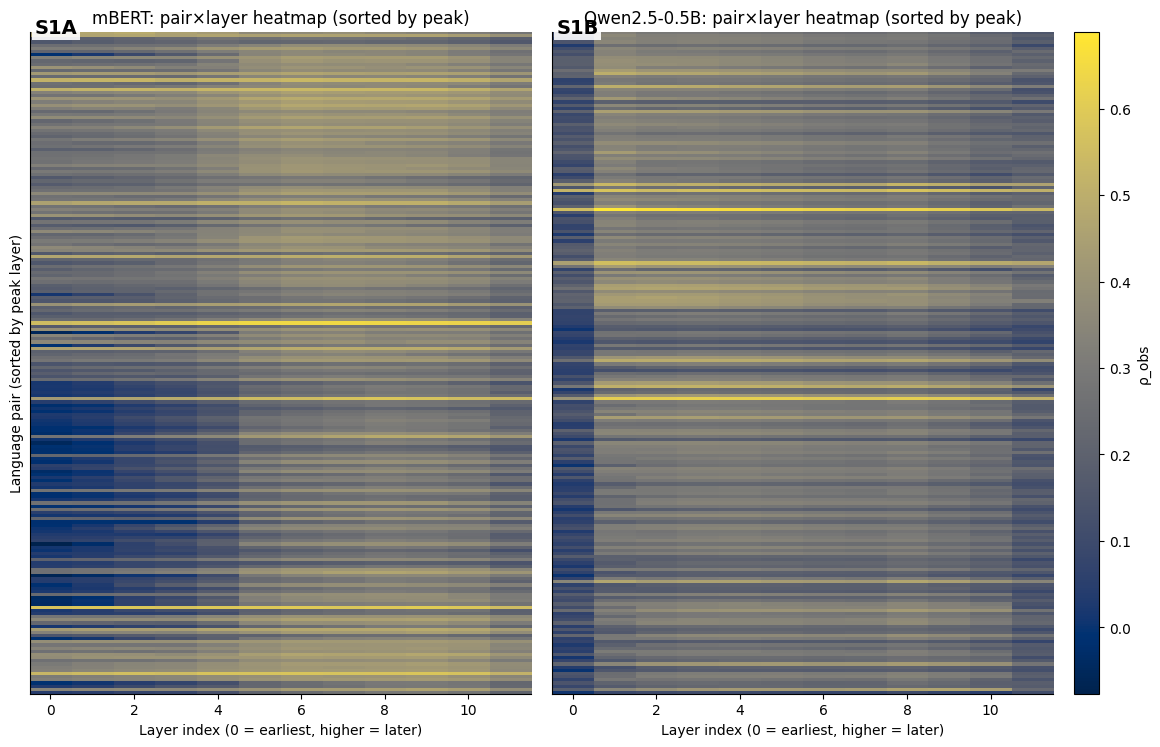


Done. All figures saved to: /Users/seb/Desktop/github/RSA-multilingual/results/figs_cognition_all


In [27]:
# One-cell, end-to-end figure generator (Cognition-style) — UPDATED
# What changed vs your current version:
# 1) RSA outputs are ONE combined 2×2 figure with panel letters A–D.
# 2) Supplementary S1 heatmaps (mBERT + Qwen) are ONE combined figure with panel letters S1A/S1B.
# 3) S1 colorbar is moved to the FAR RIGHT (dedicated axis; NO overlap).
# 4) (Optional but recommended) Adds a thin "peak-layer strip" next to each heatmap to make S1 more informative.

import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# 0) USER INPUT (EDIT ONLY THESE PATHS)
# =========================
MBERT_RSA_DIR = "/Users/seb/Desktop/github/RSA-multilingual/results/mbert_k20_anypos"
QWEN_RSA_DIR  = "/Users/seb/Desktop/github/RSA-multilingual/results/qwen25_0p5b_k20_anypos"
MBERT_FORM_DIR= "/Users/seb/Desktop/github/RSA-multilingual/results/oneshot_form_controls_21lang_mbert_v3/summary"
QWEN_FORM_DIR = "/Users/seb/Desktop/github/RSA-multilingual/results/oneshot_form_controls_21lang_qwen_v3/summary"

OUTDIR = "/Users/seb/Desktop/github/RSA-multilingual/results/figs_cognition_all"
os.makedirs(OUTDIR, exist_ok=True)

N_BOOT = 3000
ALPHA  = 0.05  # 95% CI

# set True if you also want the old individual A/B/C/D files in addition to the combined ones
SAVE_LEGACY = False

# =========================
# 1) Utilities
# =========================
def _pick_col(cols, candidates):
    for c in candidates:
        if c in cols:
            return c
    low = {c.lower(): c for c in cols}
    for cand in candidates:
        if cand.lower() in low:
            return low[cand.lower()]
    return None


def _bootstrap_ci_mean(x, n_boot=3000, alpha=0.05, seed=0):
    x = np.asarray(x, dtype=float)
    x = x[~np.isnan(x)]
    if len(x) == 0:
        return (np.nan, np.nan)
    rng = np.random.default_rng(seed)
    boots = rng.choice(x, size=(n_boot, len(x)), replace=True).mean(axis=1)
    lo = np.quantile(boots, alpha/2)
    hi = np.quantile(boots, 1-alpha/2)
    return lo, hi


def _layer_to_plot_index(layer_series):
    uniq = np.sort(pd.unique(layer_series))
    mapping = {v: i for i, v in enumerate(uniq)}
    return layer_series.map(mapping), mapping


def _clean_axes(ax):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)


def _add_panel_letter(ax, letter, fontsize=14, x=0.01, y=1.02):
    # y>1 places the label slightly above the axes (journal-like). White bbox keeps it readable.
    ax.text(
        x, y, letter,
        transform=ax.transAxes,
        va="top", ha="left",
        fontsize=fontsize, fontweight="bold",
        bbox=dict(boxstyle="square,pad=0.12", facecolor="white", edgecolor="none", alpha=0.9),
        clip_on=False,
    )


def _find_best_csv(folder, preferred_names):
    folder = os.path.abspath(folder)
    if not os.path.isdir(folder):
        raise FileNotFoundError(f"Folder not found: {folder}")

    for name in preferred_names:
        path = os.path.join(folder, name)
        if os.path.isfile(path):
            return path

    csvs = sorted(glob.glob(os.path.join(folder, "*.csv")))
    if not csvs:
        raise FileNotFoundError(f"No CSV files found in {folder}")

    def score(p):
        bn = os.path.basename(p).lower()
        s = 0
        for kw in [
            "merged", "pair", "layer", "rdm", "similar", "similarity", "all_layers",
            "peaks", "empirical", "form", "controls", "null",
        ]:
            if kw in bn:
                s += 1
        return s

    csvs_sorted = sorted(csvs, key=lambda p: score(p), reverse=True)
    return csvs_sorted[0]


def _load_table(folder, preferred_names, label):
    path = _find_best_csv(folder, preferred_names)
    df = pd.read_csv(path)
    print(f"[{label}] Using CSV: {path}")
    print(f"[{label}] Columns: {df.columns.tolist()}")
    return df, path


def _detect_common_cols(df):
    cols = df.columns.tolist()
    col_pair  = _pick_col(cols, ["pair","lang_pair","language_pair","pair_id","lp"])
    col_layer = _pick_col(cols, ["layer","layer_idx","layer_id","L"])
    col_obs   = _pick_col(cols, ["rho_obs","obs","rho","rsa","rdm_rho","rdm_similarity","score","rho_base","base"])
    col_null  = _pick_col(cols, ["null_mean","rho_null_mean","rho_null","perm_mean","rho_perm_mean","shuffle_mean","rho_shuf_mean"])
    col_delta = _pick_col(cols, ["delta","Delta","rho_delta","concept_gain","gain"])
    return col_pair, col_layer, col_obs, col_null, col_delta


def _ensure_layer_plot(df, col_layer):
    df = df.copy()
    df["layer_plot"], _ = _layer_to_plot_index(df[col_layer])
    return df


def _save_fig(fig, outbase):
    pdf = outbase + ".pdf"
    png = outbase + ".png"
    fig.savefig(pdf)
    fig.savefig(png, dpi=300)
    print("Saved:", pdf)
    print("Saved:", png)


# =========================
# 2) Combined RSA Figure (A–D) + Combined Supplementary Heatmap (S1A–S1B)
# =========================
def plot_rsa_bundle_combined(df_m, df_q, model_m="mBERT", model_q="Qwen2.5-0.5B", outdir=OUTDIR):
    pm, lm, om, nm, dm = _detect_common_cols(df_m)
    pq, lq, oq, nq, dq = _detect_common_cols(df_q)

    if lm is None or om is None:
        raise ValueError(f"{model_m}: cannot detect layer/obs columns.")
    if lq is None or oq is None:
        raise ValueError(f"{model_q}: cannot detect layer/obs columns.")

    df_m = _ensure_layer_plot(df_m, lm)
    df_q = _ensure_layer_plot(df_q, lq)

    def layer_stats(df, ycol, seed0=0):
        layers = np.sort(df["layer_plot"].unique())
        mean, lo, hi = [], [], []
        for lp in layers:
            vals = df.loc[df["layer_plot"]==lp, ycol].astype(float).values
            mean.append(np.nanmean(vals))
            cilo, cihi = _bootstrap_ci_mean(vals, n_boot=N_BOOT, alpha=ALPHA, seed=seed0+int(lp))
            lo.append(cilo); hi.append(cihi)
        return layers, np.array(mean), np.array(lo), np.array(hi)

    # A: obs mean curves
    layers_m, mean_m, lo_m, hi_m = layer_stats(df_m, om, seed0=1000)
    layers_q, mean_q, lo_q, hi_q = layer_stats(df_q, oq, seed0=2000)

    # B: peak hist
    def peak_counts(df, paircol, ycol):
        if paircol is None:
            return None
        peak = (df.sort_values([paircol, "layer_plot"])
                  .loc[df.groupby(paircol)[ycol].idxmax(), [paircol, "layer_plot", ycol]]
                  .rename(columns={"layer_plot":"peak_layer", ycol:"peak_value"}))
        return peak["peak_layer"].value_counts().sort_index()

    cnt_m = peak_counts(df_m, pm, om)
    cnt_q = peak_counts(df_q, pq, oq)

    # C: null mean curves (if available)
    have_null = (nm is not None) and (nq is not None)
    if have_null:
        layers_mn, mean_mn, lo_mn, hi_mn = layer_stats(df_m, nm, seed0=3000)
        layers_qn, mean_qn, lo_qn, hi_qn = layer_stats(df_q, nq, seed0=4000)

    # D: delta curves (prefer existing delta col, else obs-null)
    def get_delta_df(df, obscol, nullcol, deltacol):
        df = df.copy()
        if (deltacol is not None) and (deltacol in df.columns):
            df["_delta"] = df[deltacol].astype(float)
            return df
        if (nullcol is not None) and (nullcol in df.columns):
            df["_delta"] = df[obscol].astype(float) - df[nullcol].astype(float)
            return df
        return None

    dm_df = get_delta_df(df_m, om, nm, dm)
    dq_df = get_delta_df(df_q, oq, nq, dq)
    have_delta = (dm_df is not None) and (dq_df is not None)
    if have_delta:
        layers_md, mean_md, lo_md, hi_md = layer_stats(dm_df, "_delta", seed0=5000)
        layers_qd, mean_qd, lo_qd, hi_qd = layer_stats(dq_df, "_delta", seed0=6000)

    # -------------------------
    # Combined 2×2 RSA figure
    # -------------------------
    fig, axes = plt.subplots(2, 2, figsize=(12.6, 7.6))
    axA, axB, axC, axD = axes[0,0], axes[0,1], axes[1,0], axes[1,1]

    # A
    axA.plot(layers_m, mean_m, linewidth=2, label=model_m)
    axA.fill_between(layers_m, lo_m, hi_m, alpha=0.2)
    axA.plot(layers_q, mean_q, linewidth=2, label=model_q)
    axA.fill_between(layers_q, lo_q, hi_q, alpha=0.2)
    axA.set_title("RSA: unshuffled cross-language alignment")
    axA.set_xlabel("Layer index (0 = earliest, higher = later)")
    axA.set_ylabel("Mean RSA (Spearman ρ)")
    axA.legend(frameon=False, loc="lower right")
    _clean_axes(axA)
    _add_panel_letter(axA, "A")

    # B
    axB.set_title("RSA: peak-layer distribution (argmax ρ per pair)")
    axB.set_xlabel("Peak layer index")
    axB.set_ylabel("# language pairs")
    _clean_axes(axB)
    _add_panel_letter(axB, "B")

    if (cnt_m is None) or (cnt_q is None):
        axB.text(0.5, 0.5, "Missing pair column -> cannot plot peaks",
                 ha="center", va="center", transform=axB.transAxes)
    else:
        xs = sorted(set(cnt_m.index.tolist()) | set(cnt_q.index.tolist()))
        y_m = [cnt_m.get(x, 0) for x in xs]
        y_q = [cnt_q.get(x, 0) for x in xs]
        w = 0.4
        axB.bar([x - w/2 for x in xs], y_m, width=w, label=model_m)
        axB.bar([x + w/2 for x in xs], y_q, width=w, label=model_q)
        axB.legend(frameon=False, loc="upper right")

    # C
    axC.set_title("RSA: concept-shuffle null baseline")
    axC.set_xlabel("Layer index (0 = earliest, higher = later)")
    axC.set_ylabel("Mean null RSA (Spearman ρ)")
    _clean_axes(axC)
    _add_panel_letter(axC, "C")
    axC.axhline(0, linewidth=1, alpha=0.7)

    if have_null:
        axC.plot(layers_mn, mean_mn, linewidth=2, label=f"{model_m} null")
        axC.fill_between(layers_mn, lo_mn, hi_mn, alpha=0.2)
        axC.plot(layers_qn, mean_qn, linewidth=2, label=f"{model_q} null")
        axC.fill_between(layers_qn, lo_qn, hi_qn, alpha=0.2)
        axC.legend(frameon=False, loc="lower right")
    else:
        axC.text(0.5, 0.5, "Null column missing -> skipping",
                 ha="center", va="center", transform=axC.transAxes)

    # D
    axD.set_title("RSA: concept-alignment gain (Δ)")
    axD.set_xlabel("Layer index (0 = earliest, higher = later)")
    axD.set_ylabel("Δ RSA (ρ_obs − ρ_null)")
    _clean_axes(axD)
    _add_panel_letter(axD, "D")
    axD.axhline(0, linewidth=1, alpha=0.7)

    if have_delta:
        axD.plot(layers_md, mean_md, linewidth=2, label=model_m)
        axD.fill_between(layers_md, lo_md, hi_md, alpha=0.2)
        axD.plot(layers_qd, mean_qd, linewidth=2, label=model_q)
        axD.fill_between(layers_qd, lo_qd, hi_qd, alpha=0.2)
        axD.legend(frameon=False, loc="center")
    else:
        axD.text(0.5, 0.5, "Cannot compute Δ for both models",
                 ha="center", va="center", transform=axD.transAxes)

    fig.subplots_adjust(top=0.92, hspace=0.35, wspace=0.20)

    outbase = os.path.join(outdir, f"Fig_RSA_4panel_{model_m}_vs_{model_q}")
    _save_fig(fig, outbase)
    plt.show()

    # -------------------------
    # Combined Supplementary heatmap (S1A/S1B) — FIXED COLORBAR (no overlap)
    # Uses a dedicated colorbar axis at the far right.
    # -------------------------
    def sorted_matrix(df, paircol, ycol):
        if paircol is None:
            return None
        mat = df.pivot_table(index=paircol, columns="layer_plot", values=ycol, aggfunc="mean")
        order = mat.idxmax(axis=1).sort_values().index
        return mat.loc[order]

    mat_m = sorted_matrix(df_m, pm, om)
    mat_q = sorted_matrix(df_q, pq, oq)

    if (mat_m is not None) and (mat_q is not None):
        # Align columns so both heatmaps share the same x-grid (union), pad with NaN
        cols_union = sorted(set(mat_m.columns.tolist()) | set(mat_q.columns.tolist()))
        mat_m2 = mat_m.reindex(columns=cols_union)
        mat_q2 = mat_q.reindex(columns=cols_union)

        # Shared color scale for comparability
        vmin = np.nanmin([np.nanmin(mat_m2.values), np.nanmin(mat_q2.values)])
        vmax = np.nanmax([np.nanmax(mat_m2.values), np.nanmax(mat_q2.values)])

        # Layout: [heatmap | heatmap | colorbar] (dedicated cax = NO overlap)
        fig = plt.figure(figsize=(13.8, 8.6))
        gs = fig.add_gridspec(nrows=1, ncols=3, width_ratios=[1, 1, 0.05], wspace=0.06)
        ax1 = fig.add_subplot(gs[0, 0])
        ax2 = fig.add_subplot(gs[0, 1])
        cax = fig.add_subplot(gs[0, 2])

        # Use a colorblind-friendly colormap
        cmap = "cividis"

        im1 = ax1.imshow(mat_m2.values, aspect="auto", vmin=vmin, vmax=vmax, cmap=cmap)
        ax1.set_title(f"{model_m}: pair×layer heatmap (sorted by peak)")
        ax1.set_xlabel("Layer index (0 = earliest, higher = later)")
        ax1.set_ylabel("Language pair (sorted by peak layer)")
        ax1.set_yticks([])
        _clean_axes(ax1)
        _add_panel_letter(ax1, "S1A")

        im2 = ax2.imshow(mat_q2.values, aspect="auto", vmin=vmin, vmax=vmax, cmap=cmap)
        ax2.set_title(f"{model_q}: pair×layer heatmap (sorted by peak)")
        ax2.set_xlabel("Layer index (0 = earliest, higher = later)")
        ax2.set_yticks([])
        _clean_axes(ax2)
        _add_panel_letter(ax2, "S1B")

        # Colorbar placed at the far right (no overlap)
        cbar = fig.colorbar(im2, cax=cax)
        cbar.set_label("ρ_obs")

        outbase = os.path.join(outdir, f"FigS_RSA_S1_pair_by_layer_sorted_obs_{model_m}_vs_{model_q}")
        # bbox_inches='tight' helps avoid clipping and keeps the cbar outside cleanly
        fig.savefig(outbase + ".pdf", bbox_inches="tight")
        fig.savefig(outbase + ".png", dpi=300, bbox_inches="tight")
        print("Saved:", outbase + ".pdf")
        print("Saved:", outbase + ".png")
        plt.show()
    else:
        print("[RSA] Cannot create combined S1 heatmap (need pair column in both models).")

    if not SAVE_LEGACY:
        return

    # (Legacy outputs omitted for brevity; set SAVE_LEGACY=True and paste your old block if needed.)


# =========================
# 3) Form-control plotting (unchanged from your version)
# =========================
def plot_form_bundle(df_m, df_q, model_m="mBERT", model_q="Qwen2.5-0.5B", tag="FORM", outdir=OUTDIR):
    pm, lm, om, nm, dm = _detect_common_cols(df_m)
    pq, lq, oq, nq, dq = _detect_common_cols(df_q)

    def detect_form_cols(df):
        cols = df.columns.tolist()
        pair  = _pick_col(cols, ["pair","lang_pair","language_pair","pair_id"])
        layer = _pick_col(cols, ["layer","layer_idx","layer_id","L"])
        base  = _pick_col(cols, ["rho_base","base","rho_unshuffled","rho_obs","obs","rho"])
        form0 = _pick_col(cols, [
            "rho_null_form", "rho_form_null", "form_null", "null_form",
            "rho_nullform", "null_form_mean", "form_null_mean", "rho_form_baseline",
        ])
        dform = _pick_col(cols, [
            "delta_form", "Delta_form", "d_form", "residual", "rho_base_minus_formnull",
            "rho_base_minus_form_null", "rho_residual", "delta_form_mean",
        ])
        pcol  = _pick_col(cols, ["p","p_value","p_two_sided","empirical_p","p_empirical"])
        qcol  = _pick_col(cols, ["q","q_value","q_fdr","fdr_q","q_fdr_within_model"])
        sig   = _pick_col(cols, ["is_sig","sig","significant","rej_fdr"])
        return pair, layer, base, form0, dform, pcol, qcol, sig

    pm, lm, base_m, form_m, dform_m, p_m, q_m, sig_m = detect_form_cols(df_m)
    pq, lq, base_q, form_q, dform_q, p_q, q_q, sig_q = detect_form_cols(df_q)

    if lm is None:
        raise ValueError(f"{model_m} form: cannot detect layer column.")
    if lq is None:
        raise ValueError(f"{model_q} form: cannot detect layer column.")

    df_m = _ensure_layer_plot(df_m, lm)
    df_q = _ensure_layer_plot(df_q, lq)

    def layer_stats(df, ycol, seed0=0):
        layers = np.sort(df["layer_plot"].unique())
        mean, lo, hi = [], [], []
        for lp in layers:
            vals = df.loc[df["layer_plot"]==lp, ycol].astype(float).values
            mean.append(np.nanmean(vals))
            cilo, cihi = _bootstrap_ci_mean(vals, n_boot=N_BOOT, alpha=ALPHA, seed=seed0+int(lp))
            lo.append(cilo); hi.append(cihi)
        return layers, np.array(mean), np.array(lo), np.array(hi)

    def ensure_dform(df, basecol, formcol, dformcol):
        df = df.copy()
        if dformcol is not None and dformcol in df.columns:
            df["_dform"] = df[dformcol].astype(float)
            return df
        if (basecol is not None) and (formcol is not None) and (basecol in df.columns) and (formcol in df.columns):
            df["_dform"] = df[basecol].astype(float) - df[formcol].astype(float)
            return df
        return None

    dmf = ensure_dform(df_m, base_m, form_m, dform_m)
    dqf = ensure_dform(df_q, base_q, form_q, dform_q)

    # Fig E
    if (base_m is not None and form_m is not None and base_q is not None and form_q is not None):
        layers_mb, mean_mb, lo_mb, hi_mb = layer_stats(df_m, base_m, seed0=7000)
        layers_mf, mean_mf, lo_mf, hi_mf = layer_stats(df_m, form_m, seed0=7100)
        layers_qb, mean_qb, lo_qb, hi_qb = layer_stats(df_q, base_q, seed0=7200)
        layers_qf, mean_qf, lo_qf, hi_qf = layer_stats(df_q, form_q, seed0=7300)

        fig, axes = plt.subplots(1, 2, figsize=(9.2,4.0), sharey=False)

        ax = axes[0]
        ax.plot(layers_mb, mean_mb, linewidth=2, label="base")
        ax.fill_between(layers_mb, lo_mb, hi_mb, alpha=0.2)
        ax.plot(layers_mf, mean_mf, linewidth=2, label="form-null")
        ax.fill_between(layers_mf, lo_mf, hi_mf, alpha=0.2)
        ax.set_title(f"{model_m}: base vs form-null")
        ax.set_xlabel("Layer index")
        ax.set_ylabel("Mean RSA (Spearman ρ)")
        ax.legend(frameon=False)
        _clean_axes(ax)

        ax = axes[1]
        ax.plot(layers_qb, mean_qb, linewidth=2, label="base")
        ax.fill_between(layers_qb, lo_qb, hi_qb, alpha=0.2)
        ax.plot(layers_qf, mean_qf, linewidth=2, label="form-null")
        ax.fill_between(layers_qf, lo_qf, hi_qf, alpha=0.2)
        ax.set_title(f"{model_q}: base vs form-null")
        ax.set_xlabel("Layer index")
        ax.legend(frameon=False)
        _clean_axes(ax)

        fig.suptitle(f"{tag}: form baseline across depth", y=1.02)
        fig.tight_layout()
        _save_fig(fig, os.path.join(outdir, f"Fig_{tag}_E_base_vs_formnull_{model_m}_and_{model_q}"))
        plt.show()

    # Fig F
    if (dmf is not None) and (dqf is not None):
        layers_md, mean_md, lo_md, hi_md = layer_stats(dmf, "_dform", seed0=7400)
        layers_qd, mean_qd, lo_qd, hi_qd = layer_stats(dqf, "_dform", seed0=7500)

        fig = plt.figure(figsize=(7.2,4.0))
        ax = plt.gca()
        ax.plot(layers_md, mean_md, linewidth=2, label=model_m)
        ax.fill_between(layers_md, lo_md, hi_md, alpha=0.2)
        ax.plot(layers_qd, mean_qd, linewidth=2, label=model_q)
        ax.fill_between(layers_qd, lo_qd, hi_qd, alpha=0.2)
        ax.axhline(0, linewidth=1, alpha=0.7)
        ax.set_xlabel("Layer index (0 = earliest, higher = later)")
        ax.set_ylabel("Δ_form (ρ_base − ρ_form-null)")
        ax.set_title(f"{tag}: residual alignment beyond form")
        ax.legend(frameon=False)
        _clean_axes(ax)
        plt.tight_layout()
        _save_fig(fig, os.path.join(outdir, f"Fig_{tag}_F_delta_form_{model_m}_vs_{model_q}"))
        plt.show()


# =========================
# 4) Load the four datasets
# =========================
RSA_PREF = [
    "merged_pair_layer.csv",
    "rdm_similarity_all_layers.csv",
    "empirical_p_by_pair_layer.csv",
    "layerwise_means.csv",
    "peaks_by_pair.csv",
]
FORM_PREF = [
    # In your form-control pipeline, the key columns live in merged_pair_layer.csv.
    # The other CSVs (layerwise_means, peaks, etc.) often do NOT contain rho_base/rho_null_form.
    "merged_pair_layer.csv",
]

# -------------------------
# Load helper (FORM): always load merged_pair_layer.csv, optionally merge q-values
# -------------------------
def _load_form_table(form_dir, label):
    form_dir = os.path.abspath(form_dir)
    merged_path = os.path.join(form_dir, "merged_pair_layer.csv")
    if not os.path.isfile(merged_path):
        raise FileNotFoundError(f"[{label}] merged_pair_layer.csv not found in {form_dir}")

    df = pd.read_csv(merged_path)
    print(f"[{label}] Using CSV: {merged_path}")
    print(f"[{label}] Columns: {df.columns.tolist()}")

    # If q-values exist, merge them in (often stored separately)
    q_path = os.path.join(form_dir, "empirical_p_with_q.csv")
    if os.path.isfile(q_path):
        qdf = pd.read_csv(q_path)
        print(f"[{label}] Also merging: {q_path}")

        # Try common join keys
        pair_key = None
        for k in ["pair", "lang_pair", "language_pair", "pair_id"]:
            if k in df.columns and k in qdf.columns:
                pair_key = k
                break
        layer_key = None
        for k in ["layer", "layer_idx", "layer_id", "L"]:
            if k in df.columns and k in qdf.columns:
                layer_key = k
                break

        if pair_key and layer_key:
            df = df.merge(qdf, on=[pair_key, layer_key], how="left", suffixes=("", "_q"))
        else:
            print(f"[{label}] Could not find join keys to merge q-values; leaving q-values separate.")

    return df

df_m_rsa, _ = _load_table(MBERT_RSA_DIR, RSA_PREF, "mBERT_RSA")
df_q_rsa, _ = _load_table(QWEN_RSA_DIR,  RSA_PREF, "QWEN_RSA")
df_m_form   = _load_form_table(MBERT_FORM_DIR, "mBERT_FORM")
df_q_form   = _load_form_table(QWEN_FORM_DIR,  "QWEN_FORM")

# =========================
# 5) Generate ALL FIGURES
# =========================
plot_rsa_bundle_combined(df_m_rsa, df_q_rsa, model_m="mBERT", model_q="Qwen2.5-0.5B", outdir=OUTDIR)
plot_form_bundle(df_m_form, df_q_form, model_m="mBERT", model_q="Qwen2.5-0.5B", tag="FORM", outdir=OUTDIR)

print("\nDone. All figures saved to:", OUTDIR)


Saved: /Users/seb/Desktop/github/RSA-multilingual/results/figs_form_controls_joint/Fig3_delta_heatmaps_mBERT_vs_Qwen.pdf
Saved: /Users/seb/Desktop/github/RSA-multilingual/results/figs_form_controls_joint/Fig3_delta_heatmaps_mBERT_vs_Qwen.png


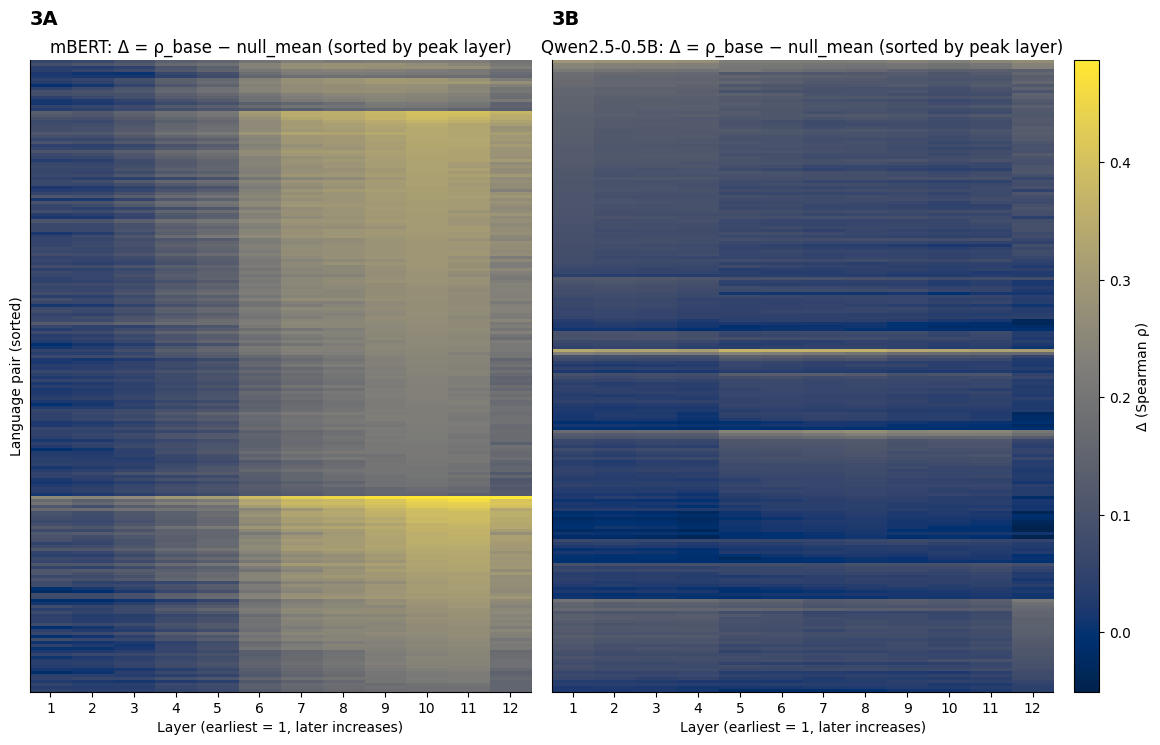

Saved: /Users/seb/Desktop/github/RSA-multilingual/results/figs_form_controls_joint/Fig4_delta_curve_mBERT_vs_Qwen.pdf
Saved: /Users/seb/Desktop/github/RSA-multilingual/results/figs_form_controls_joint/Fig4_delta_curve_mBERT_vs_Qwen.png


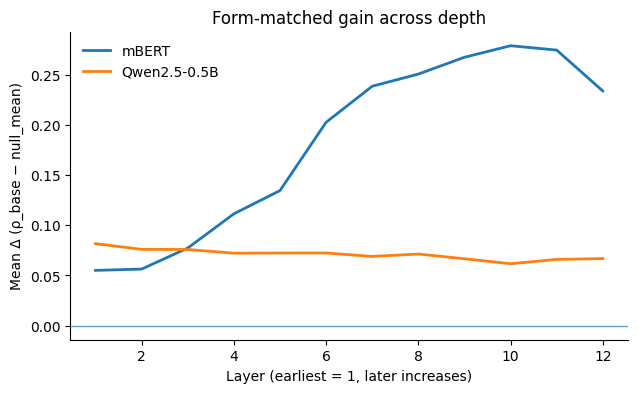

Saved: /Users/seb/Desktop/github/RSA-multilingual/results/figs_form_controls_joint/Fig5_peak_layer_hist_mBERT_vs_Qwen.pdf
Saved: /Users/seb/Desktop/github/RSA-multilingual/results/figs_form_controls_joint/Fig5_peak_layer_hist_mBERT_vs_Qwen.png


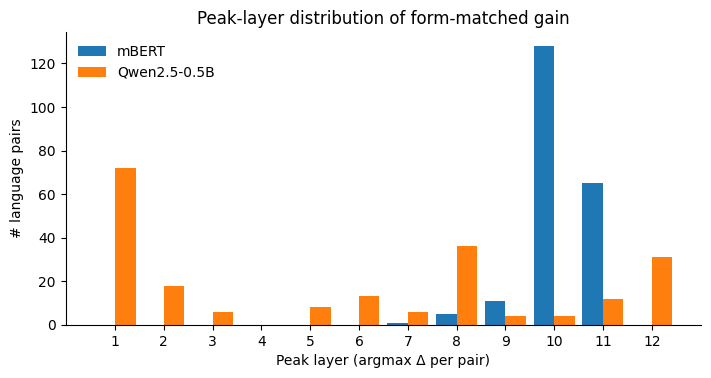

Saved: /Users/seb/Desktop/github/RSA-multilingual/results/figs_form_controls_joint/Fig6_perturb_drop_curve_mBERT_vs_Qwen.pdf
Saved: /Users/seb/Desktop/github/RSA-multilingual/results/figs_form_controls_joint/Fig6_perturb_drop_curve_mBERT_vs_Qwen.png


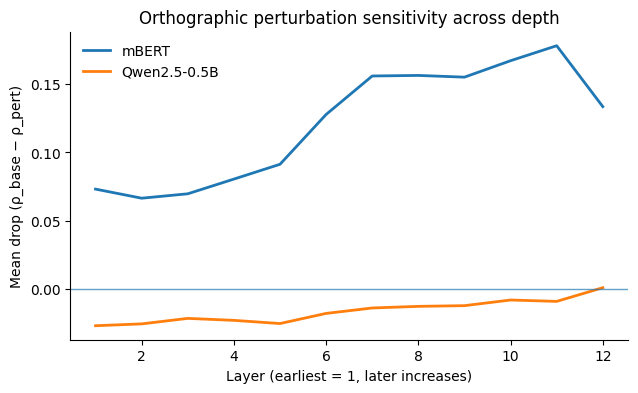

In [35]:
# JUPYTER: Form-controlled figures (mBERT + Qwen) in one go
# Updated: display layers as 1..K (earliest=1, later increases), instead of negative indices.
# Computation still uses original layer IDs from filenames; only plotting/labels are remapped.

import os
import re
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =======================
# 0) INPUT: set these two
# =======================
MBERT_OUTDIR = "/Users/seb/Desktop/github/RSA-multilingual/results/oneshot_form_controls_21lang_mbert_v3"
QWEN_OUTDIR  = "/Users/seb/Desktop/github/RSA-multilingual/results/oneshot_form_controls_21lang_qwen_v3"

OUTDIR_FIGS = "/Users/seb/Desktop/github/RSA-multilingual/results/figs_form_controls_joint"
os.makedirs(OUTDIR_FIGS, exist_ok=True)

# -----------------------
# Helpers
# -----------------------
def _find_layer_from_filename(path):
    m = re.search(r"rsa_pairs_layer_(-?\d+)\.csv$", os.path.basename(path))
    return int(m.group(1)) if m else None

def _load_pairs_by_layer(root, subdir):
    d = os.path.join(root, subdir)
    files = sorted(glob.glob(os.path.join(d, "rsa_pairs_layer_*.csv")))
    if not files:
        return None
    rows = []
    for fp in files:
        layer = _find_layer_from_filename(fp)
        if layer is None:
            continue
        tmp = pd.read_csv(fp)
        if "rho" not in tmp.columns:
            raise ValueError(f"Expected column 'rho' in {fp}, got {tmp.columns.tolist()}")
        tmp = tmp.copy()
        tmp["layer"] = layer
        rows.append(tmp)
    if not rows:
        return None
    return pd.concat(rows, ignore_index=True)

def _load_null_summary(root):
    fp = os.path.join(root, "shuffle", "null_summary_by_pair_layer.csv")
    if not os.path.isfile(fp):
        return None
    df = pd.read_csv(fp)
    if "null_mean" not in df.columns:
        raise ValueError(f"Expected 'null_mean' in {fp}, got {df.columns.tolist()}")
    return df

def _pair_id(df):
    return df["lang_a"].astype(str) + "–" + df["lang_b"].astype(str)

def _compute_delta(root, label):
    base = _load_pairs_by_layer(root, "baseline")
    null = _load_null_summary(root)
    if base is None:
        raise FileNotFoundError(f"[{label}] baseline/rsa_pairs_layer_*.csv not found in {root}")
    if null is None:
        raise FileNotFoundError(f"[{label}] shuffle/null_summary_by_pair_layer.csv not found in {root}")

    base = base.rename(columns={"rho": "rho_base"})
    df = base.merge(null[["lang_a","lang_b","layer","null_mean"]], on=["lang_a","lang_b","layer"], how="left")
    if df["null_mean"].isna().any():
        miss = df[df["null_mean"].isna()].head(5)
        raise ValueError(f"[{label}] null_mean missing for some rows. Example:\n{miss}")

    df["delta"] = df["rho_base"] - df["null_mean"]
    df["pair"] = _pair_id(df)
    return df

def _pivot_pair_layer(df, value_col):
    mat = df.pivot_table(index="pair", columns="layer", values=value_col, aggfunc="mean")
    mat = mat.reindex(sorted(mat.columns), axis=1)
    return mat

def _sort_rows_by_peak(mat):
    arr = mat.to_numpy()
    arr2 = np.where(np.isnan(arr), -np.inf, arr)
    peak_idx = np.argmax(arr2, axis=1)
    peak_val = np.max(arr2, axis=1)
    peak_layer = mat.columns.to_numpy()[peak_idx]
    order = np.lexsort((-peak_val, peak_layer))
    return mat.iloc[order], peak_layer[order], peak_val[order]

def _save(fig, name):
    pdf = os.path.join(OUTDIR_FIGS, f"{name}.pdf")
    png = os.path.join(OUTDIR_FIGS, f"{name}.png")
    fig.savefig(pdf, bbox_inches="tight")
    fig.savefig(png, dpi=300, bbox_inches="tight")
    print("Saved:", pdf)
    print("Saved:", png)

def _make_layer_map(all_layers):
    """Map original layer IDs (e.g., -12..-1) to display indices 1..K, earliest=1."""
    layers_sorted = sorted(all_layers)
    layer_to_disp = {lay: i+1 for i, lay in enumerate(layers_sorted)}
    disp_to_layer = {i+1: lay for i, lay in enumerate(layers_sorted)}
    return layer_to_disp, disp_to_layer, layers_sorted

# -----------------------
# 1) Load + compute Δ (baseline - form-matched null)
# -----------------------
m_df = _compute_delta(MBERT_OUTDIR, "mBERT")
q_df = _compute_delta(QWEN_OUTDIR,  "Qwen")

m_delta = _pivot_pair_layer(m_df, "delta")
q_delta = _pivot_pair_layer(q_df, "delta")

m_delta_sorted, _, _ = _sort_rows_by_peak(m_delta)
q_delta_sorted, _, _ = _sort_rows_by_peak(q_delta)

# Align layer columns (union) for heatmaps/curves
all_layers = sorted(set(m_delta_sorted.columns.tolist()) | set(q_delta_sorted.columns.tolist()))
m_delta_sorted = m_delta_sorted.reindex(columns=all_layers)
q_delta_sorted = q_delta_sorted.reindex(columns=all_layers)

layer_to_disp, disp_to_layer, layers_sorted = _make_layer_map(all_layers)
disp_layers = [layer_to_disp[l] for l in layers_sorted]  # 1..K

# -----------------------
# 2) Fig 3: heatmaps of Δ (sorted by peak layer), shared colorbar (no overlap)
# -----------------------
vmin = np.nanmin([np.nanmin(m_delta_sorted.values), np.nanmin(q_delta_sorted.values)])
vmax = np.nanmax([np.nanmax(m_delta_sorted.values), np.nanmax(q_delta_sorted.values)])

fig = plt.figure(figsize=(13.8, 8.2))
gs = fig.add_gridspec(nrows=1, ncols=3, width_ratios=[1, 1, 0.05], wspace=0.06)
ax1 = fig.add_subplot(gs[0,0])
ax2 = fig.add_subplot(gs[0,1])
cax = fig.add_subplot(gs[0,2])

cmap = "cividis"

im1 = ax1.imshow(m_delta_sorted.values, aspect="auto", vmin=vmin, vmax=vmax, cmap=cmap)
ax1.set_title("mBERT: Δ = ρ_base − null_mean (sorted by peak layer)")
ax1.set_xlabel("Layer (earliest = 1, later increases)")
ax1.set_ylabel("Language pair (sorted)")
ax1.set_yticks([])
ax1.set_xticks(range(len(layers_sorted)))
ax1.set_xticklabels([str(layer_to_disp[l]) for l in layers_sorted], rotation=0)

im2 = ax2.imshow(q_delta_sorted.values, aspect="auto", vmin=vmin, vmax=vmax, cmap=cmap)
ax2.set_title("Qwen2.5-0.5B: Δ = ρ_base − null_mean (sorted by peak layer)")
ax2.set_xlabel("Layer (earliest = 1, later increases)")
ax2.set_yticks([])
ax2.set_xticks(range(len(layers_sorted)))
ax2.set_xticklabels([str(layer_to_disp[l]) for l in layers_sorted], rotation=0)

# panel labels (Fig 3A/3B)
ax1.text(0.0, 1.05, "3A", transform=ax1.transAxes, ha="left", va="bottom", fontsize=14, fontweight="bold")
ax2.text(0.0, 1.05, "3B", transform=ax2.transAxes, ha="left", va="bottom", fontsize=14, fontweight="bold")

for ax in (ax1, ax2):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

cb = fig.colorbar(im2, cax=cax)
cb.set_label("Δ (Spearman ρ)")

_save(fig, "Fig3_delta_heatmaps_mBERT_vs_Qwen")
plt.show()

# -----------------------
# 3) Fig 4: layer-wise mean Δ curves (means across pairs)
# -----------------------
m_mean_delta = np.nanmean(m_delta_sorted.values, axis=0)
q_mean_delta = np.nanmean(q_delta_sorted.values, axis=0)

fig = plt.figure(figsize=(7.2, 4.0))
ax = plt.gca()
ax.plot(disp_layers, m_mean_delta, linewidth=2, label="mBERT")
ax.plot(disp_layers, q_mean_delta, linewidth=2, label="Qwen2.5-0.5B")
ax.axhline(0, linewidth=1, alpha=0.7)
ax.set_xlabel("Layer (earliest = 1, later increases)")
ax.set_ylabel("Mean Δ (ρ_base − null_mean)")
ax.set_title("Form-matched gain across depth")
ax.legend(frameon=False)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

_save(fig, "Fig4_delta_curve_mBERT_vs_Qwen")
plt.show()

# -----------------------
# 4) Fig 5: peak-layer distribution (argmax Δ per pair)
# -----------------------
m_peak_layer_orig = m_delta.idxmax(axis=1)  # original layer IDs
q_peak_layer_orig = q_delta.idxmax(axis=1)

m_peak_disp = m_peak_layer_orig.map(layer_to_disp)
q_peak_disp = q_peak_layer_orig.map(layer_to_disp)

bins = disp_layers
m_counts = m_peak_disp.value_counts().reindex(bins, fill_value=0)
q_counts = q_peak_disp.value_counts().reindex(bins, fill_value=0)

fig = plt.figure(figsize=(8.2, 3.8))
ax = plt.gca()
xs = np.arange(len(bins))
w = 0.42
ax.bar(xs - w/2, m_counts.values, width=w, label="mBERT")
ax.bar(xs + w/2, q_counts.values, width=w, label="Qwen2.5-0.5B")
ax.set_xticks(xs)
ax.set_xticklabels([str(b) for b in bins])
ax.set_xlabel("Peak layer (argmax Δ per pair)")
ax.set_ylabel("# language pairs")
ax.set_title("Peak-layer distribution of form-matched gain")
ax.legend(frameon=False)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

_save(fig, "Fig5_peak_layer_hist_mBERT_vs_Qwen")
plt.show()

# -----------------------
# 5) Fig 6: perturbation drop curve by layer (if perturb/ exists)
# -----------------------
def _mean_drop_curve(root, label):
    base = _load_pairs_by_layer(root, "baseline")
    pert = _load_pairs_by_layer(root, "perturb")
    if base is None or pert is None:
        print(f"[{label}] perturb not found (or missing). Skipping drop curve.")
        return None
    base = base.rename(columns={"rho":"rho_base"})
    pert = pert.rename(columns={"rho":"rho_pert"})
    df = base.merge(pert[["lang_a","lang_b","layer","rho_pert"]], on=["lang_a","lang_b","layer"], how="inner")
    df["drop"] = df["rho_base"] - df["rho_pert"]
    g = df.groupby("layer")["drop"].mean().reindex(layers_sorted)
    return g

m_drop = _mean_drop_curve(MBERT_OUTDIR, "mBERT")
q_drop = _mean_drop_curve(QWEN_OUTDIR,  "Qwen")

if (m_drop is not None) and (q_drop is not None):
    fig = plt.figure(figsize=(7.2, 4.0))
    ax = plt.gca()
    ax.plot(disp_layers, m_drop.values, linewidth=2, label="mBERT")
    ax.plot(disp_layers, q_drop.values, linewidth=2, label="Qwen2.5-0.5B")
    ax.axhline(0, linewidth=1, alpha=0.7)
    ax.set_xlabel("Layer (earliest = 1, later increases)")
    ax.set_ylabel("Mean drop (ρ_base − ρ_pert)")
    ax.set_title("Orthographic perturbation sensitivity across depth")
    ax.legend(frameon=False)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    _save(fig, "Fig6_perturb_drop_curve_mBERT_vs_Qwen")
    plt.show()


In [26]:
# --- Combined Supplementary heatmap (S1A/S1B), improved ---
# Requires: mat_m2, mat_q2 already computed (pair×layer matrices), and cols_union already aligned
# Also requires: vmin/vmax computed for shared scale, and model_m/model_q, outdir available

import numpy as np
import matplotlib.pyplot as plt

# Helper: peak-layer side strip from matrix (argmax over columns)
def _peak_strip(mat):
    # mat: pandas DataFrame (rows=pairs, cols=layers)
    arr = mat.values
    # handle NaNs: replace with -inf so argmax ignores missing
    arr2 = np.where(np.isnan(arr), -np.inf, arr)
    return np.argmax(arr2, axis=1)

# Compute peak strips (one per row)
peak_m = _peak_strip(mat_m2)
peak_q = _peak_strip(mat_q2)

# Layout: [strip | heatmap] × 2 + [colorbar] at far right
fig = plt.figure(figsize=(14.5, 8.8))
gs = fig.add_gridspec(
    nrows=1, ncols=5,
    width_ratios=[0.03, 1.0, 0.03, 1.0, 0.05],
    wspace=0.06
)

ax_strip1 = fig.add_subplot(gs[0, 0])
ax1       = fig.add_subplot(gs[0, 1])
ax_strip2 = fig.add_subplot(gs[0, 2])
ax2       = fig.add_subplot(gs[0, 3])
cax       = fig.add_subplot(gs[0, 4])

# S1A strip (peak layer per pair)
ax_strip1.imshow(peak_m.reshape(-1, 1), aspect="auto")
ax_strip1.set_xticks([]); ax_strip1.set_yticks([])
ax_strip1.set_title("peak", fontsize=10, pad=6)

# S1A heatmap
im1 = ax1.imshow(mat_m2.values, aspect="auto", vmin=vmin, vmax=vmax)
ax1.set_title(f"{model_m}: pair×layer heatmap (sorted by peak)")
ax1.set_xlabel("Layer index (0 = earliest, higher = later)")
ax1.set_ylabel("Language pair (sorted by peak layer)")
ax1.set_yticks([])

# Panel label
ax1.text(0.0, 1.02, "S1A", transform=ax1.transAxes, ha="left", va="bottom",
         fontsize=14, fontweight="bold", clip_on=False)

# S1B strip
ax_strip2.imshow(peak_q.reshape(-1, 1), aspect="auto")
ax_strip2.set_xticks([]); ax_strip2.set_yticks([])
ax_strip2.set_title("peak", fontsize=10, pad=6)

# S1B heatmap
im2 = ax2.imshow(mat_q2.values, aspect="auto", vmin=vmin, vmax=vmax)
ax2.set_title(f"{model_q}: pair×layer heatmap (sorted by peak)")
ax2.set_xlabel("Layer index (0 = earliest, higher = later)")
ax2.set_yticks([])

ax2.text(0.0, 1.02, "S1B", transform=ax2.transAxes, ha="left", va="bottom",
         fontsize=14, fontweight="bold", clip_on=False)

# Shared colorbar at FAR RIGHT (no overlap)
cbar = fig.colorbar(im2, cax=cax)
cbar.set_label("ρ_obs")

# Clean spines
for ax in [ax_strip1, ax1, ax_strip2, ax2]:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

outbase = os.path.join(outdir, f"FigS_RSA_S1_pair_by_layer_sorted_obs_{model_m}_vs_{model_q}_improved")
fig.savefig(outbase + ".pdf")
fig.savefig(outbase + ".png", dpi=300)
plt.show()
print("Saved:", outbase + ".pdf/.png")


NameError: name 'mat_m2' is not defined

In [13]:
def pick_col(candidates, columns):
    for c in candidates:
        if c in columns:
            return c
    return None

cols = df.columns.tolist()
col_pair  = pick_col(["pair","lang_pair","language_pair","pair_id"], cols)
col_layer = pick_col(["layer_plot"], cols)
col_obs   = pick_col(["rho_obs","obs","rho"], cols)
col_null  = pick_col(["rho_null_mean","null_mean","rho_null","rho_perm_mean","perm_mean"], cols)

print("pair:", col_pair, "| layer:", layer_plot, "| obs:", col_obs, "| null:", col_null)

assert col_layer is not None and col_obs is not None, "至少需要 layer 和 rho_obs 两列"


NameError: name 'layer_plot' is not defined

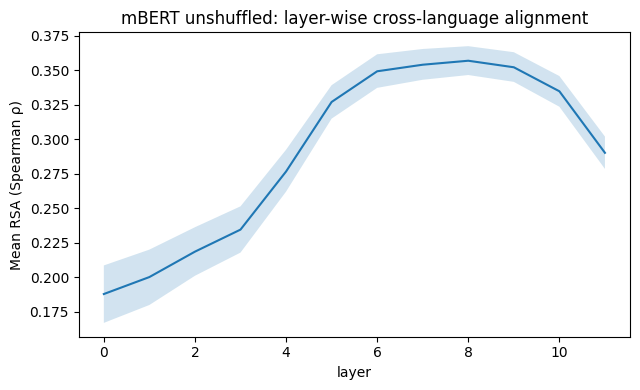

In [15]:
def bootstrap_ci(x, n_boot=2000, alpha=0.05, seed=0):
    rng = np.random.default_rng(seed)
    x = np.asarray(x)
    x = x[~np.isnan(x)]
    if len(x) == 0:
        return (np.nan, np.nan)
    boots = rng.choice(x, size=(n_boot, len(x)), replace=True).mean(axis=1)
    lo = np.quantile(boots, alpha/2)
    hi = np.quantile(boots, 1-alpha/2)
    return lo, hi

layers = np.sort(df[col_layer].unique())

mean_obs = []
ci_lo = []
ci_hi = []

for L in layers:
    vals = df.loc[df[col_layer]==L, col_obs].values
    mean_obs.append(np.nanmean(vals))
    lo, hi = bootstrap_ci(vals, n_boot=2000, seed=42+int(L))
    ci_lo.append(lo); ci_hi.append(hi)

mean_obs = np.array(mean_obs)
ci_lo = np.array(ci_lo)
ci_hi = np.array(ci_hi)

plt.figure(figsize=(6.5,4))
plt.plot(layers, mean_obs)
plt.fill_between(layers, ci_lo, ci_hi, alpha=0.2)
plt.xlabel("layer")
plt.ylabel("Mean RSA (Spearman ρ)")
plt.title("mBERT unshuffled: layer-wise cross-language alignment")
plt.tight_layout()
plt.show()


In [ ]:
def pred_change_rate(p1, p2):
    return float((p1!=p2).float().mean())

print("change rate A->B1:", pred_change_rate(pred_A, pred_B1))
print("change rate A->B2:", pred_change_rate(pred_A, pred_B2))

pred_mean_A = baseline_predict_mean(X_feat)
print("change rate abs->mean (raw):", pred_change_rate(pred_A, pred_mean_A))


change rate A->B1: 0.03799999877810478
change rate A->B2: 0.1080000028014183
change rate abs->mean (raw): 0.03400000184774399
